# AlphaLab — Value + Momentum Factor Strategy

A cross-sectional equity strategy on the S&P 500 universe:

- **Factors:** trailing P/E (value, lower is better) and 6-month price momentum (higher is better)
- **Selection:** stocks are ranked on each factor, ranks are averaged, and the top 5 composite names are held equal-weight
- **Rebalancing:** quarterly, point-in-time — each rebalance only sees prices up to that date
- **Evaluation:** out-of-sample test window (last 30% of the data), benchmarked against SPY

All strategy logic lives in the `alphalab` package (`src/alphalab/`); this notebook just drives it and inspects the results.

In [1]:
%load_ext autoreload
%autoreload 2

from datetime import date, timedelta

from alphalab import (
    Momentum,
    Settings,
    Value,
    compute_factor_table,
    holdings_frame,
    load_fundamentals,
    load_prices,
    load_universe,
    metrics_table,
    plot_cumulative_returns,
    run_backtest,
    select_stocks,
    train_test_split_index,
)

## Parameters

Edit `Settings` here to change the run — everything downstream reads from it.

In [2]:
settings = Settings()  # defaults: 100 stocks, 2 years, top 5, quarterly rebalance
end = date.today()
start = end - timedelta(days=settings.data_years * 365)
settings

Settings(data_years=2, split_ratio=0.7, top_n_stocks=5, universe_size=100, benchmark_ticker='SPY', starting_amount=10000.0, rebalance_freq='QS', momentum_lookback_days=126, risk_free_rate=0.0, trading_days_per_year=252)

## Universe

Top S&P 500 names by market cap, from a cached snapshot (`data/sp500_market_caps.csv`).
Pass `refresh=True` to rebuild it — that makes one yfinance request per ticker, so it is off by default.

In [3]:
universe = load_universe()
tickers = universe["Ticker"].head(settings.universe_size).tolist()
universe.head(10)

,Ticker,MarketCap,CompanyName
0,NVDA,4066436186112,NVIDIA Corporation
1,MSFT,3679419105280,Microsoft Corporation
2,AAPL,3557095374848,Apple Inc.
3,GOOGL,2843006468096,Alphabet Inc.
4,AMZN,2477776175104,"Amazon.com, Inc."
5,META,1890259828736,"Meta Platforms, Inc."
6,AVGO,1575145177088,Broadcom Inc.
7,BMYMP,1288246919168,Bristol-Myers Squibb Company PFD CONV 2
8,TSLA,1131616796672,"Tesla, Inc."
9,BRK-B,1078403661824,Berkshire Hathaway Inc.


## Prices and train/test split

One batch download of adjusted daily closes, cached to parquet in `data/cache/` so reruns are offline.
The split is chronological: the first 70% of days is the training window (used only as factor lookback history), the last 30% is the out-of-sample test window where returns are measured.

In [4]:
prices = load_prices(tickers, start, end)
train_index, test_index = train_test_split_index(prices.index, settings.split_ratio)

print(f"{prices.shape[1]} tickers, {prices.shape[0]} trading days")
print(f"Train: {train_index[0].date()} to {train_index[-1].date()} ({len(train_index)} days)")
print(f"Test:  {test_index[0].date()} to {test_index[-1].date()} ({len(test_index)} days)")

98 tickers, 501 trading days
Train: 2024-07-17 to 2025-12-05 (350 days)
Test:  2025-12-08 to 2026-07-16 (151 days)


## Factors

- **Momentum** — trailing 126-trading-day (~6 month) return, computed from prices up to the evaluation date only.
- **Value** — trailing P/E = price *as of the evaluation date* divided by trailing-12-month EPS. The price side is fully point-in-time; the EPS side is a single snapshot (`data/fundamentals.csv`) because yfinance only exposes ~4–5 quarters of income statements, which cannot reconstruct historical TTM EPS honestly. This is a known, documented approximation (see the README's limitations section). Negative-earnings names get NaN P/E and fall back to their momentum rank.

As a sanity check, here is the selection the strategy would have made **at the end of the training period** — the last date before any test returns are earned:

In [5]:
eps = load_fundamentals(tickers)
factors = [Value(eps), Momentum(settings.momentum_lookback_days)]

as_of = train_index[-1]
table = compute_factor_table(prices, as_of, factors)
selected = select_stocks(table, factors, settings.top_n_stocks)

print(f"Selection as of end of training period ({as_of.date()}): {selected}")
table.loc[selected].round(2)

Selection as of end of training period (2025-12-05): ['MU', 'C', 'GS', 'MS', 'BAC']


,trailing_pe,momentum_126d
Ticker,,
MU,5.35,1.19
C,11.60,0.41
GS,13.07,0.41
MS,14.10,0.36
BAC,12.33,0.21


## Backtest

Quarterly rebalances over the test window. At each rebalance date the factor table is recomputed from prices up to that date, the top names are selected, and the portfolio is held equal-weight until the next rebalance.

In [6]:
result = run_backtest(
    prices, factors, settings.top_n_stocks, test_index, settings.rebalance_freq
)
holdings_frame(result)

,#1,#2,#3,#4,#5
2025-12-08,MU,C,GS,MS,BAC
2026-01-01,MU,C,GS,MS,WFC
2026-04-01,MU,CB,VZ,GILD,C
2026-07-01,MO,C,CB,GS,MS


## Performance vs SPY

Both series are measured over the same test dates and pushed through the same metrics function, so the annualized figures share a denominator.

In [7]:
from alphalab import load_benchmark

benchmark_prices = load_benchmark(settings.benchmark_ticker, start, end)
benchmark_returns = (
    benchmark_prices.pct_change().reindex(result.daily_returns.index).dropna()
)
benchmark_cum = (1 + benchmark_returns).cumprod()

metrics_table(
    {"Strategy": result.daily_returns, settings.benchmark_ticker: benchmark_returns},
    trading_days_per_year=settings.trading_days_per_year,
    risk_free_rate=settings.risk_free_rate,
).round(4)

,Strategy,SPY
total_return,0.4181,0.1039
annualized_return,0.7914,0.1794
annualized_vol,0.2590,0.1340
sharpe_ratio,3.0554,1.3385
n_days,151.0000,151.0000


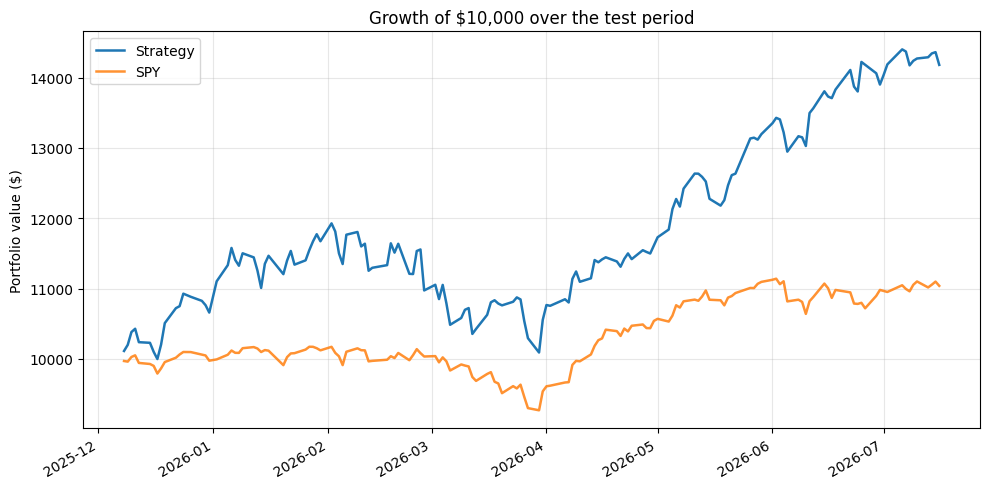

In [8]:
fig = plot_cumulative_returns(
    result.cum_returns,
    benchmark_cum,
    starting_amount=settings.starting_amount,
    benchmark_label=settings.benchmark_ticker,
)

## Known limitations and roadmap

Honest caveats worth stating up front:

- **Survivorship bias** — the universe is *today's* S&P 500 membership applied historically; companies that left the index are missing.
- **Frozen EPS** — the value factor's earnings side is a current snapshot, not point-in-time (yfinance limitation, discussed above). Prices are point-in-time.
- **No transaction costs or slippage** — quarterly turnover of a 5-stock book is modest, but costs are not modeled.
- **Single train/test split** — one out-of-sample window; results are sensitive to the specific period.

Planned improvements: max drawdown and turnover metrics, a simple transaction-cost model, walk-forward evaluation, and a point-in-time universe.